# Course assessment: project part "stock data" (M. Garcin)

## Numerical processing of financial data

#### Objective
The goal of this project is to assess the risk and the performance of a simple portfolio.

- Please write commented code. You can also use text cells for your comments and explanations.
- The code must follow the good coding principles (it must be clean, readable, etc.).
- Graphs must have a title, a legend and their axes must be labeled.
- At the end, submit your notebooks __and a pdf file of 5 to 8 pages__ into the Moodle Assignment you will find in the section "Assessment: projects".
This separate pdf file is intended to be a (very) short paper : a standalone document that summarizes the work you have carried out in the notebooks and the results you have obtained (being they positive or negative), with figures. It has to be self-contained in the sense that one has to be able to read your report and understand its content without having to look into your notebooks, which will be checked afterwards.


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import time

In [2]:
from rich.progress import Progress

# Dataset

You will use the dataset (Excel files) of one-minute observations (OHLC prices) provided in Moodle for TP1 (Session 1). The dataset consists in the 40 constituents of the French stock index CAC 40 (as of 2022/2023). The biggest capitalizations are: LVMH (MC), L'Oréal (OR), TotalEnergies (TTE), Sanofi (SAN), Hermès (RMS), Airbus (AIR)...

You have first to restrict arbitrarily your investment universe to ten of these stocks and work with this universe for all the project.

The time range is September 2022-March 2023. Pay attention to the fact that some stocks don't have a price every minute (less liquid, like SW): avoid them.



In [12]:
# %pip install openpyxl  # if needed

begin_date = pd.to_datetime("2022-09-01")
end_date = pd.to_datetime("2023-03-01")

folder_path = 'data/'
df = pd.DataFrame()

with Progress() as p:
    t = p.add_task("[red]Processing files...", total=len(os.listdir(folder_path)))

    for i, filename in enumerate(os.listdir(folder_path)):
        if filename.endswith('.xlsx'):
            file_path = os.path.join(folder_path, filename)

            sub_df = pd.read_excel(file_path, engine='openpyxl', header=1)

            # Enforcing convert to datetime
            if pd.api.types.is_numeric_dtype(sub_df['Dates']):
                sub_df['Dates'] = pd.to_datetime(sub_df['Dates'], unit='d', origin='1899-12-30', errors='coerce')
                
            sub_df = sub_df[(sub_df['Dates'] >= begin_date) & (sub_df['Dates'] <= end_date)]

            sub_df['Ticker'] = filename.split('_')[0]
            df = pd.concat([df, sub_df], ignore_index=True)
            p.update(t, advance=1)

print(df.head())
print(df.tail())

Output()

                    Dates    Open   Close    High     Low Ticker
0 2022-09-13 09:00:00.005  16.910  16.910  16.910  16.900     CA
1 2022-09-13 09:01:00.000  16.905  16.905  16.905  16.900     CA
2 2022-09-13 09:02:00.000  16.895  16.865  16.895  16.855     CA
3 2022-09-13 09:03:00.000  16.815  16.800  16.815  16.795     CA
4 2022-09-13 09:04:00.000  16.805  16.805  16.805  16.805     CA
                      Dates    Open   Close    High     Low Ticker
2256517 2023-02-28 17:27:00  1724.0  1723.0  1724.0  1722.5    RMS
2256518 2023-02-28 17:28:00  1723.5  1723.5  1723.5  1723.5    RMS
2256519 2023-02-28 17:29:00  1723.5  1721.5  1723.5  1721.5    RMS
2256520 2023-02-28 17:35:00  1715.5  1715.5  1715.5  1715.5    RMS
2256521 2023-02-28 17:36:00  1715.5  1715.5  1715.5  1715.5    RMS


/home/raynor/Lectures/X/NPoFD/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


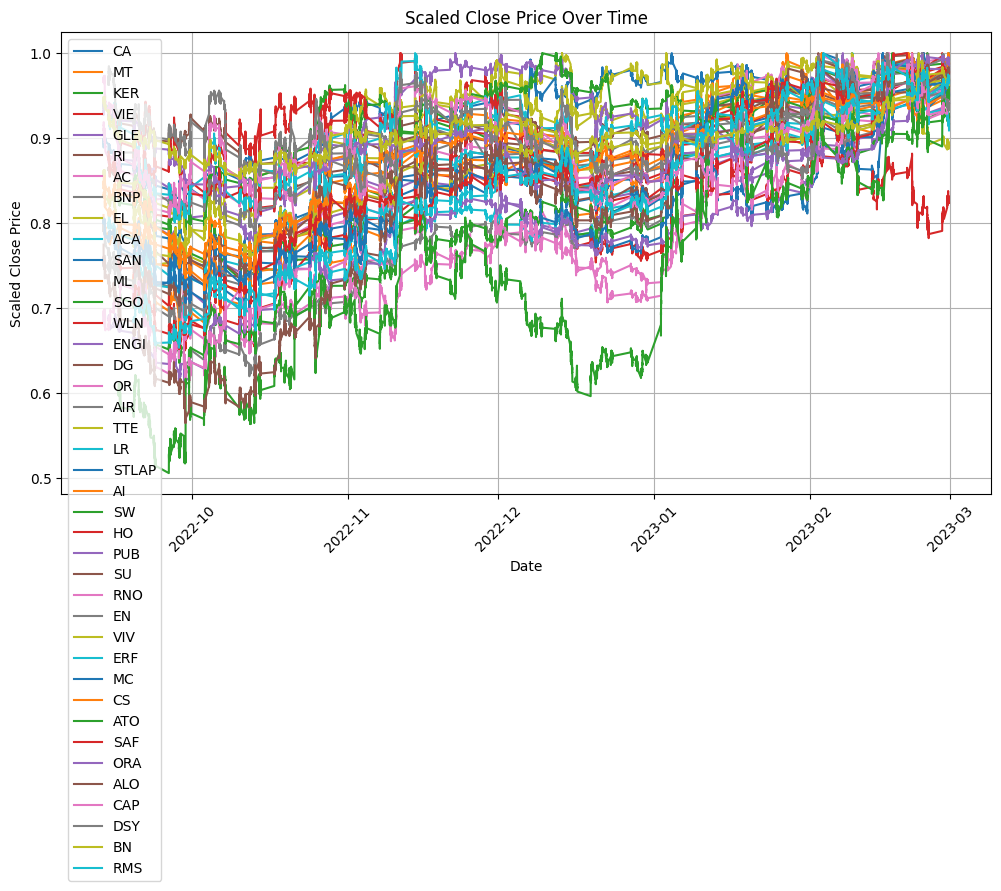

In [13]:
plt.figure(figsize=(12, 6))

for ticker in df["Ticker"].unique():
    grouped = df[df["Ticker"] == ticker]
    plt.plot(grouped["Dates"], grouped["Close"]/grouped["Close"].max(), label=f"{ticker}")

plt.title(f"Scaled Close Price Over Time")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Scaled Close Price")
plt.legend()
plt.grid()
plt.show()

# Creating a porfolio (Part 1)

* **1.a/** Split your dataset of prices in separate business days, from day 1 to day $n$. Calculate and put in a dataframe the price returns of the 10 stocks at a daily time scale.



* **1.b/** Calculate both the correlation matrix and the covariance matrix $\Sigma$ of the daily price returns of the 10 stocks.

* **1.c/** For each stock, calculate the autocorrelation of the daily time series of returns, for a lag of one day.

* **1.d/** Using only the autocorrelations calculated above and the observation of the price returns at day $i$ (for $1\leq i\leq n-1$), propose a projection $R_{i+1,j}$ of the future price return at day $i+1$ for each stock $j$ ($1\leq j\leq 10$). Justify briefly the relevance of the method.



* **1.e/** Using the above projection as a proxy for the expected return, calculate the Markowitz portfolio such that the sum of weights is equal to 1, that is the optimal vector of weights for day $i+1$ is
$$\Omega_{i+1}=\frac{1}{\mathbf{1}'_{10}\Sigma^{-1}R_{i+1}}\Sigma^{-1}R_{i+1},$$
where $R_{i+1}=(R_{i+1,1},...,R_{i+1,10})'$ and $\mathbf{1}_{10}$ is a vector of ones of size 10.



* **1.f/** Add in your dataframe the time series of realized price returns for your portfolio, between day 2 and day $n$, using the dynamic weights calculated above.



* **1.g/** What is the main methodological bias we had in the construction of this portfolio that would affect the quality of a backtest?

# Risk and performance evaluation (Part 2)

* **2.a/** Determine the ex-ante (that is using $R_{i+1,j}$ as the return) and ex-post (that is the real return observed after each trading day) Sharpe ratio of your portfolio (consider 0 as the risk-free rate).

* **2.b/** Calculate the ex-post upside potential ratio of your portfolio.

* **2.c/** Calculate the maximum drawdown of your portfolio.

* **2.d/** Using the formula presented in the course, calculate the additive contribution of each of the 10 stocks to the volatility of the portfolio.